
# LLM Router — Unified Log Loader
This notebook loads and indexes experiment runs with the unified filenames:
- `metrics.jsonl`
- `output.jsonl`
- `queue.json` (optional)
- `results.json`

It assumes your repo layout like:
```
results/
  rr-batching/
    17/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
  pull-batching/
    29/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
...
```

> **Tip:** You can change `BASE_DIR` below if your results are elsewhere.


In [172]:
import pandas as pd


from utils_analysis import (
    load_experiment,
    make_runs_index,
    normalize_metrics_samples,
    collect_results_summary,
    collect_all_metrics,
    collect_all_outputs,
    select_metrics,
    metrics_to_endpoint_tables,
    summarize_output_metric,
    draw_output_time_each,
    collect_all_queues,
    summarize_metrics_metric,
    summarize_queue_metric,
    cumulative_output_metric,
    cumulative_metrics_metric,
    cumulative_queue_metric,
    list_available_metrics_metrics,
    list_available_output_metrics,
    list_all_metrics_for_run,
    draw_violin_for_metric,
    draw_token_length_distribution_per_endpoint,
    build_tokens_by_endpoint,
    summarize_by_endpoint,
    plot_ecdf_per_method,
    plot_violins_per_method
)


BASE_DIR = "/home/saeid/llm-lb/results"  # or "results copy"
SERIES = "179"

# Put only the experiments you want to analyze here:
EXPERIMENTS = [
    # ("rr-batching", "178"),
    # ("rr-batching", "179"),
    # ("rr-batching", "180"),
    # ("rr-batching", "181"),
    # ("rr-batching", "182"),
    ("least-queue-batching", SERIES),
    ("rr-batching", SERIES),
    ("pull-batching", SERIES),
    # ("least-queue-batching", "91"),
    # ("least-queue-batching", "92"),
    # ("least-queue-batching", "93"),
    # ("rr-batching", SERIES),
    # ("least-queue-batching", SERIES),
    # ("pull-batching", SERIES),
    # ("least-queue-batching", "6"),
    # ("random-batching", "5"),
    # ("pull", "5"),
    # ("least-queue-worker", "2"),
    # ("pull-batching", "40"),
    # ("least-queue-batching", "14"),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)
# runs_index

In [173]:
method, run_id = runs_index.iloc[0][["method", "run_id"]]
exp = load_experiment(method, run_id, base_dir=BASE_DIR)

# print("Loaded sections:", list(exp.keys()))
# if "results" in exp:
#     print("results.json:", exp["results"])

# Peek at raw frames
# display(exp.get("metrics", pd.DataFrame()).head())
# display(exp.get("output", pd.DataFrame()).head())
# display(exp.get("queue", pd.DataFrame()).head())

# Normalize metrics.samples for this run
metrics_norm = normalize_metrics_samples(
    exp.get("metrics", pd.DataFrame()), method, run_id
)
print("Normalized metrics shape:", metrics_norm.shape)
# display(metrics_norm.head())

Normalized metrics shape: (872, 32)


In [174]:
results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)
queues_all = collect_all_queues(runs_index)


# display(results_summary.head())
# display(metrics_all.head())
# display(outputs_all.head())

# Optional CSVs for quick offline inspection
# runs_index.to_csv("runs_index.csv", index=False)
# if not results_summary.empty:
#     results_summary.to_csv("results_summary_flat.csv", index=False)
# print("Exports written where available")
# outputs_all

In [175]:
queues_all.columns

Index(['ts', 'mode', 'endpoint', 'model', 'status', 'prompt', 'session_idx',
       'util_pct', 'want', 'pulled', 'active_before', 'active_after',
       'backlog_before', 'backlog_after', 'logical_before', 'logical_after',
       'q_before', 'q_after', 'every_n', 'len_aware', 'len_policy',
       'pool_factor', 'method', 'run_id', 'inflight_before', 'inflight_after'],
      dtype='object')

In [176]:
# Examples (uncomment and adjust as needed):

# 1) Filter rows by one endpoint and one mode; select specific columns
# sel = select_metrics(
#     metrics_all,
#     endpoints="10.1.62.151:8200",
#     modes="rr-batching",
#     experiments=None,  # or "17" or [("rr-batching","17")]
#     columns=["ts", "method", "run_id", "mode", "instance", "gen_tokens_per_sec", "gpu_util_percent"]
# )

# 2) Filter by multiple endpoints and experiments (run_ids), keep all columns
# sel = select_metrics(
#     metrics_all,
#     endpoints=["10.1.62.151:8200","10.1.62.162:8200"],
#     modes=None,
#     experiments=["17","29"]
# )

# 3) Filter by explicit (method, run_id) pairs
# sel = select_metrics(
#     metrics_all,
#     experiments=[("rr-batching","17"), ("pull-batching","29")],
#     columns=["ts","method","run_id","instance","requests_running","gen_tokens_per_sec"]
# )

# 4) Just column projection on all aggregated metrics
# sel = select_metrics(
#     metrics_all,
#     columns=["ts","instance","gen_tokens_per_sec","gpu_util_percent"]
# )

# Choose one of the above options or define your own:
sel = select_metrics(
    metrics_all,
    endpoints=["10.1.62.151:8200", "10.1.62.162:8200"],
    modes=f"{BASE_DIR}/rr-batching",
    experiments=SERIES,
    columns=[
        "ts",
        "method",
        "run_id",
        "mode",
        "instance",
        "gen_tokens_per_sec",
        "gpu_util_percent",
    ],
)

display(sel.head())
print("Rows:", len(sel), "| Columns:", list(sel.columns))

,ts,method,run_id,mode,instance,gen_tokens_per_sec,gpu_util_percent


Rows: 0 | Columns: ['ts', 'method', 'run_id', 'mode', 'instance', 'gen_tokens_per_sec', 'gpu_util_percent']


In [177]:
# Assume you have metrics_all or metrics_norm
df_metrics = metrics_all if not metrics_all.empty else metrics_norm

endpoint_tables = metrics_to_endpoint_tables(df_metrics)
# print("Endpoints:", list(endpoint_tables.keys()))
try:
    # Example: access by endpoint
    ep = list(endpoint_tables.keys())[0]
    df_ep = endpoint_tables[ep]
    # print("First endpoint:", ep)
    # display(df_ep.head())

    # Loop over all endpoints
    # for ep, df_ep in endpoint_tables.items():
    #     print(f"\nEndpoint: {ep}, rows={len(df_ep)}")
    #     display(df_ep.head(2))
except:
    print("test")

def collect_all_queues(runs_index):
    frames = []
    for _, row in runs_index.iterrows():
        if row["queue_path"]:
            df = read_queue(row["queue_path"])
            df["method"] = row["method"]
            df["run_id"] = row["run_id"]
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

queues_all = collect_all_queues(runs_index)
queues_all.head()


In [178]:
# Just numeric output metrics (with derived) for run 42
list_available_output_metrics("rr-batching", "95", base_dir=BASE_DIR)

[]

In [179]:
# [
#   "latency_s",
#   "router_queue_wait",
#   "server_roundtrip",
#   "end_to_end_latency",
#   "measured_router_queue_wait",
#   "measured_server_roundtrip",
#   "measured_end_to_end_latency",
#   "predicted_out_tokens",
#   "actual_out_tokens",
# ]

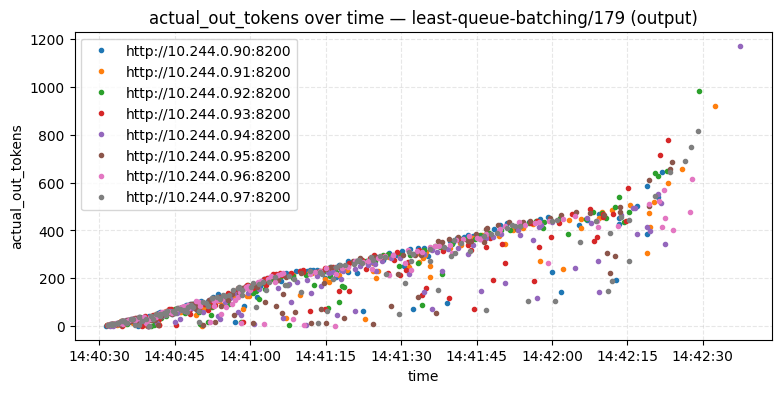

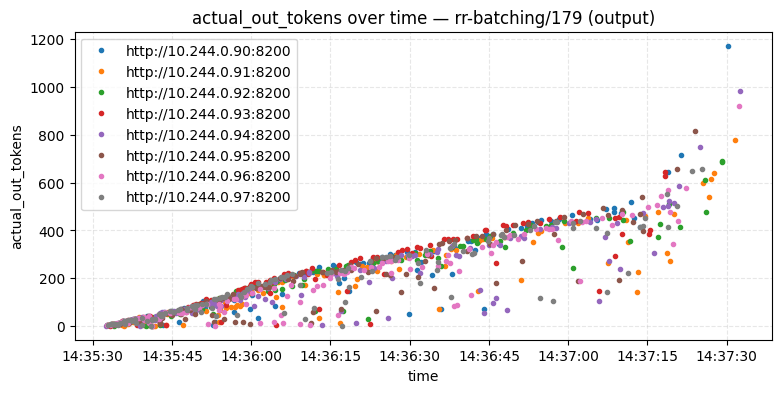

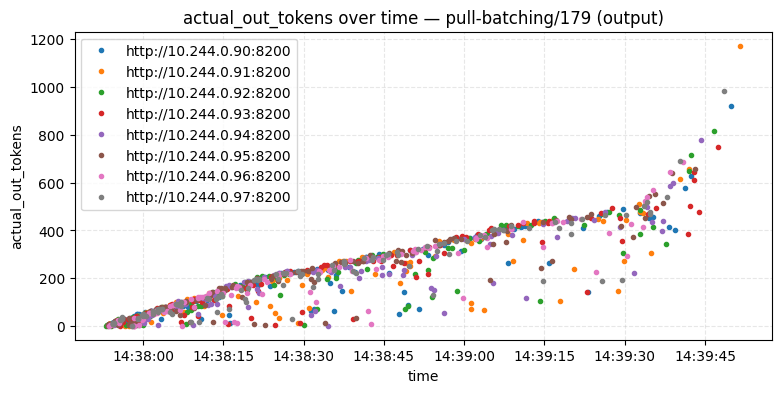

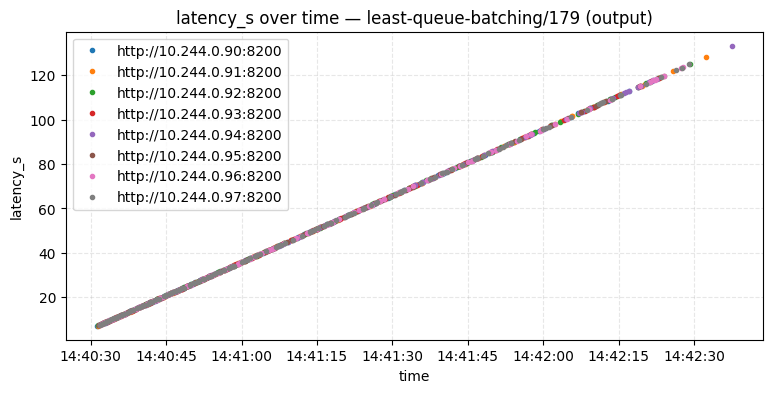

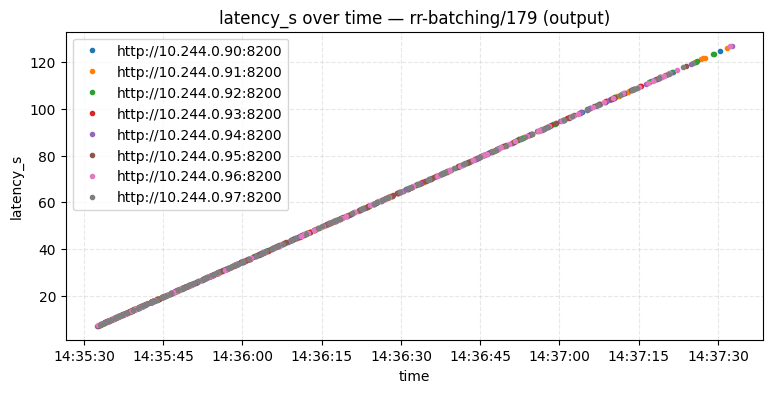

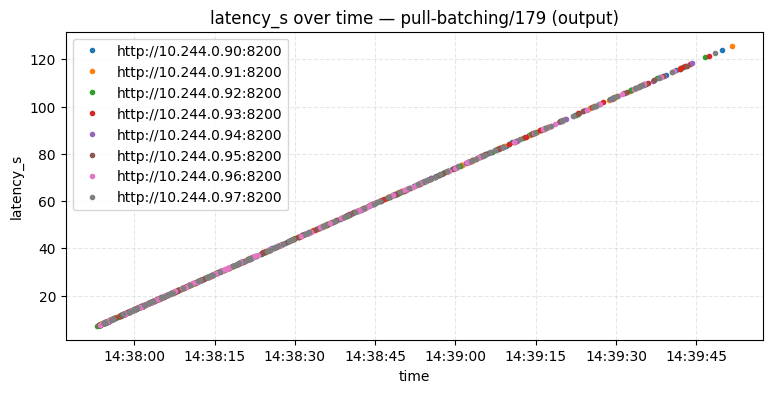

In [180]:
# 2) output.jsonl — latency per request (points), separate figures
['latency_s',
 'req_id',
 't_arrival_router',
 't_dispatch_router',
 't_response_router',
 'router_queue_wait',
 'server_roundtrip',
 'end_to_end_latency',
 'measured_router_queue_wait',
 'measured_server_roundtrip',
 'measured_end_to_end_latency',
 'input_tokens',
 "predicted_out_tokens",
 "actual_out_tokens",
 "total_predicted_tokens",
 "total_actual_tokens",
 ]

draw_output_time_each(
    EXPERIMENTS,
    metric="actual_out_tokens",
    endpoints=None,
    base_dir=BASE_DIR,
    per_request=True,  # raw events; resample ignored
    resample=None,
    title=None,
    save_path_template=None,
    # ylim=(0, 0.12),
)

draw_output_time_each(
    EXPERIMENTS,
    metric="latency_s",
    endpoints=None,
    base_dir=BASE_DIR,
    per_request=True,  # raw events; resample ignored
    resample=None,
    title=None,
    save_path_template=None,
    # ylim=(0, 0.12),
)

In [181]:
# import matplotlib.pyplot as plt

# # Plot directly from your dataframe
# plt.figure(figsize=(8, 5))
# plt.bar(results_summary["method"], results_summary["runtime_sec"], color="skyblue")
# plt.xlabel("Method")
# plt.ylabel("Runtime (sec)")
# plt.title("Runtime by Batching Method")
# plt.xticks(rotation=15)
# plt.show()

In [182]:
# metric="sim_service_s"
metric = "latency_s"

least_queue_batching_df = summarize_output_metric(
    "least-queue-batching",
    SERIES,
    metric=metric,
    percentiles=(50, 90, 99),
    base_dir=BASE_DIR,
    include_overall=True,
)

rr_batching_df = summarize_output_metric(
    "rr-batching",
    SERIES,
    metric=metric,
    percentiles=(50, 90, 99),
    base_dir=BASE_DIR,
    include_overall=True,
)

pull_batching_df = summarize_output_metric(
    "pull-batching",
    SERIES,
    metric=metric,
    percentiles=(50, 90, 99),
    base_dir=BASE_DIR,
    include_overall=True,
)

# # Save results into DataFrames
# pull_batching_df = summarize_output_metric(
#     "pull-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# least_queue_df = summarize_output_metric(
#     "least-queue-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# pull_batching_df = summarize_output_metric(
#     "pull-batching",
#     SERIES,
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# Display them
display(least_queue_batching_df)
display(rr_batching_df)
display(pull_batching_df)

# rr_batching_df1 = summarize_output_metric(
#     "rr-batching",
#     "178",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df2 = summarize_output_metric(
#     "rr-batching",
#     "179",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df3 = summarize_output_metric(
#     "rr-batching",
#     "180",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# rr_batching_df4 = summarize_output_metric(
#     "rr-batching",
#     "181",
#     metric=metric,
#     percentiles=(50, 90, 99),
#     base_dir=BASE_DIR,
#     include_overall=True,
# )

# # rr_batching_df4 = summarize_output_metric(
# #     "rr-batching",
# #     "182",
# #     metric=metric,
# #     percentiles=(50, 90, 99),
# #     base_dir=BASE_DIR,
# #     include_overall=True,
# # )

# display(rr_batching_df1)
# display(rr_batching_df2)
# display(rr_batching_df3)
# display(rr_batching_df4)

,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://10.244.0.90:8200,125,5957.663992,47.661312,31.347102,7.172158,117.619256,40.118550,95.475437,116.391505
1,http://10.244.0.91:8200,125,6235.375524,49.883004,33.129369,7.244447,128.166030,41.274166,100.619645,121.046327
2,http://10.244.0.92:8200,125,6183.380234,49.467042,32.278597,7.320891,125.092326,40.375201,98.395564,118.260407
3,http://10.244.0.93:8200,125,5962.990916,47.703927,31.054470,7.377000,118.820584,39.195084,94.687555,115.726849
4,http://10.244.0.94:8200,125,6457.512216,51.660098,33.427977,7.467794,133.282933,47.171682,103.319546,118.163493
5,http://10.244.0.95:8200,125,5970.536189,47.764290,31.345817,7.503432,119.781968,40.940609,96.715632,118.284940
6,http://10.244.0.96:8200,125,6149.909940,49.199280,32.688484,7.573719,123.703704,39.965024,96.967224,122.449457
7,http://10.244.0.97:8200,125,6172.856431,49.382851,32.661647,7.601874,124.842469,40.734450,99.573697,123.160356
8,ALL,1000,49090.225443,49.090225,32.164985,7.172158,133.282933,41.233336,99.109482,119.782727


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://10.244.0.90:8200,125,5970.224329,47.761795,30.831132,7.314529,124.833085,40.350596,94.229138,115.328668
1,http://10.244.0.91:8200,125,6351.222512,50.809780,33.501611,7.421577,126.153656,42.478517,105.645731,121.949586
2,http://10.244.0.92:8200,125,6169.224104,49.353793,32.660106,7.547523,123.690507,40.870544,98.047990,122.903302
3,http://10.244.0.93:8200,125,5760.431535,46.083452,29.623683,7.488814,112.924401,38.602537,92.150560,112.127313
4,http://10.244.0.94:8200,125,6245.111153,49.960889,32.702746,7.107559,127.104514,41.070594,101.039616,118.494072
5,http://10.244.0.95:8200,125,5928.801274,47.430410,30.146313,7.182230,118.550643,41.190634,93.150565,113.607116
6,http://10.244.0.96:8200,125,6371.021828,50.968175,32.804907,7.262684,126.897396,45.704766,99.697898,116.414395
7,http://10.244.0.97:8200,125,6084.607902,48.676863,31.773324,7.522617,119.848799,40.702958,96.286730,117.291079
8,ALL,1000,48880.644638,48.880645,31.712034,7.107559,127.104514,40.970569,98.397174,120.341229


,endpoint,count,sum,mean,std,min,max,p50,p90,p99
0,http://10.244.0.90:8200,128,5786.086602,45.203802,31.488456,8.240847,123.974460,37.320873,91.952847,116.220685
1,http://10.244.0.91:8200,129,5758.097442,44.636414,32.185253,7.756874,125.724308,38.310310,92.477434,115.669175
2,http://10.244.0.92:8200,126,5581.157023,44.294897,32.375150,7.247843,120.747479,34.744151,93.764351,116.438042
3,http://10.244.0.93:8200,126,5850.910424,46.435797,32.550492,8.415862,121.554215,38.481723,97.511714,117.807236
4,http://10.244.0.94:8200,111,5396.682423,48.618761,31.092435,8.716377,118.326155,41.007018,94.752689,113.011988
5,http://10.244.0.95:8200,136,5812.041832,42.735602,31.107350,7.553434,117.327770,33.907602,90.971568,112.358572
6,http://10.244.0.96:8200,121,5307.216254,43.861291,30.944838,7.731868,114.951449,34.068275,91.520833,111.876990
7,http://10.244.0.97:8200,123,5584.273880,45.400601,31.668463,8.452396,122.589263,38.923415,94.080549,113.979316
8,ALL,1000,45076.465881,45.076466,31.620935,7.247843,125.724308,36.777181,94.097320,116.575579


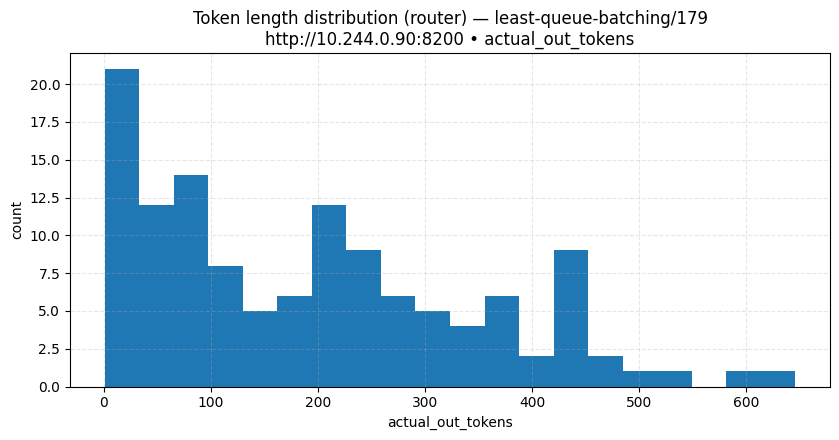

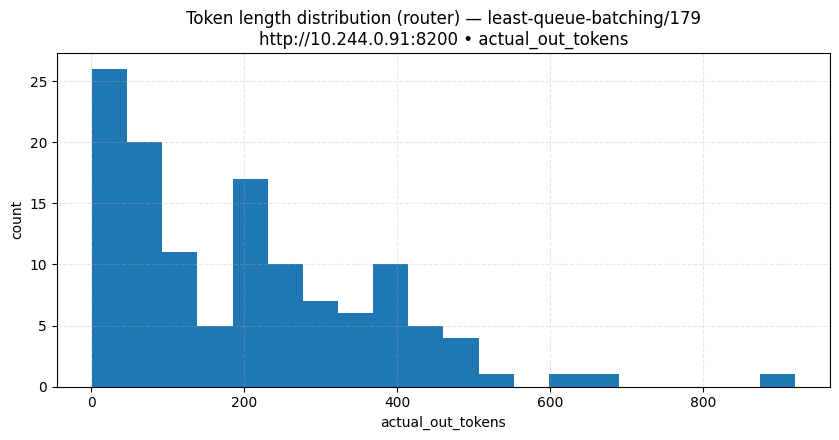

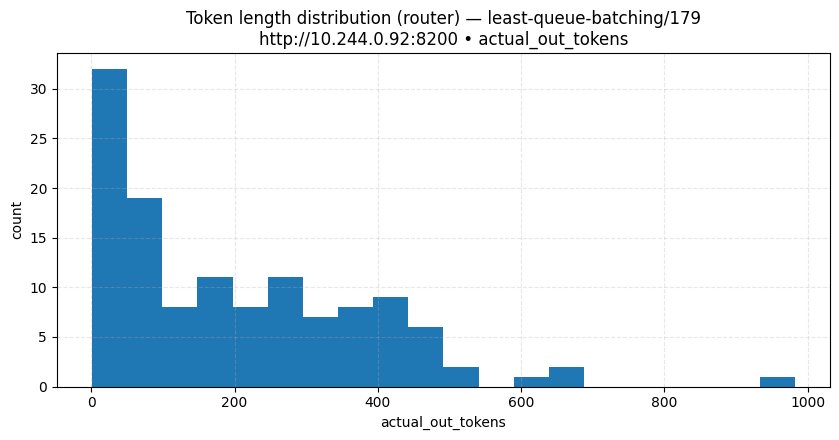

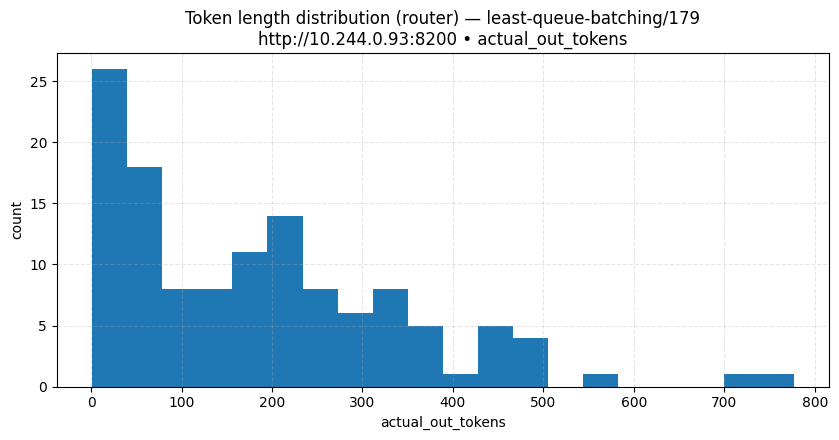

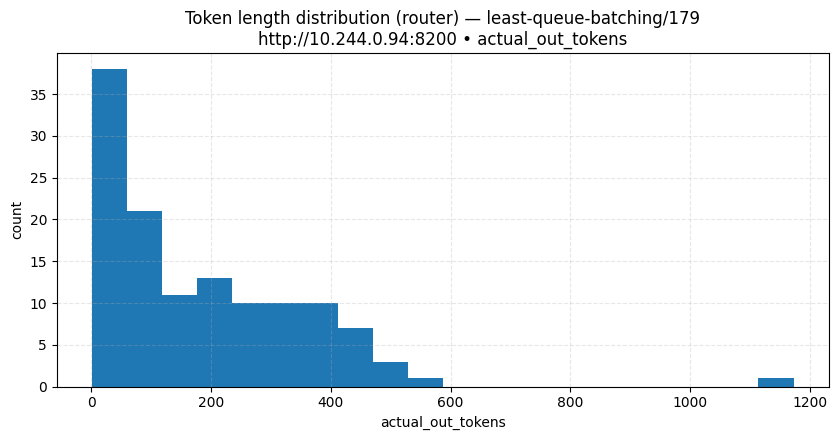

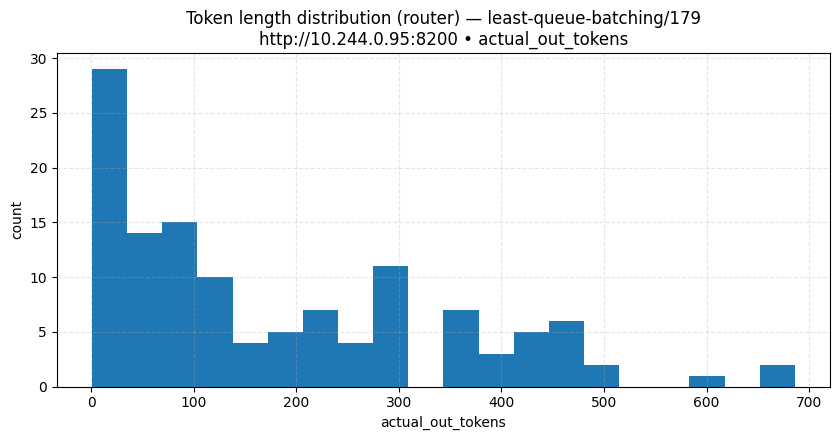

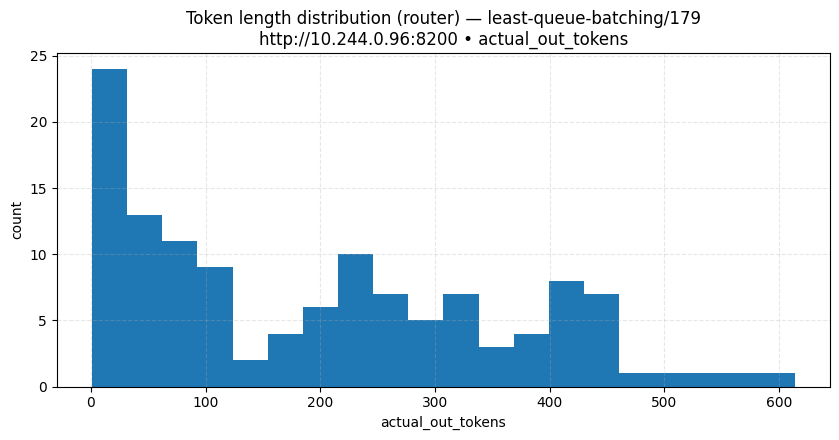

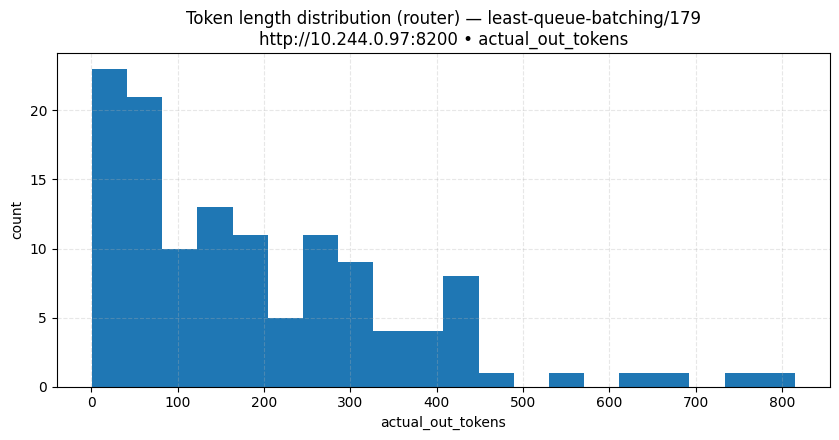

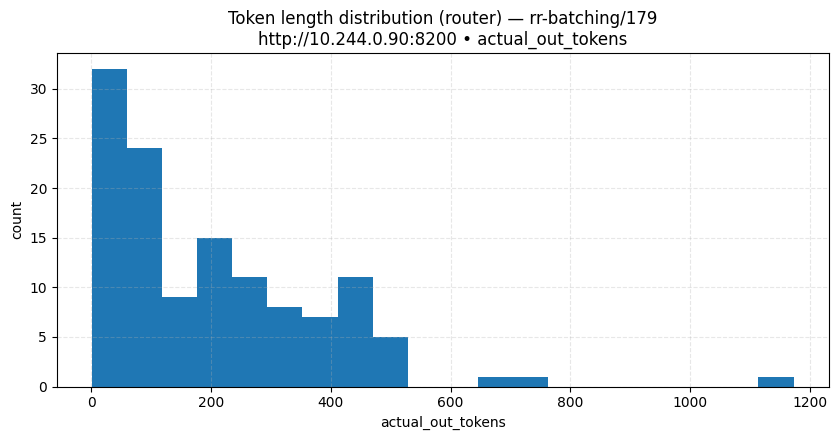

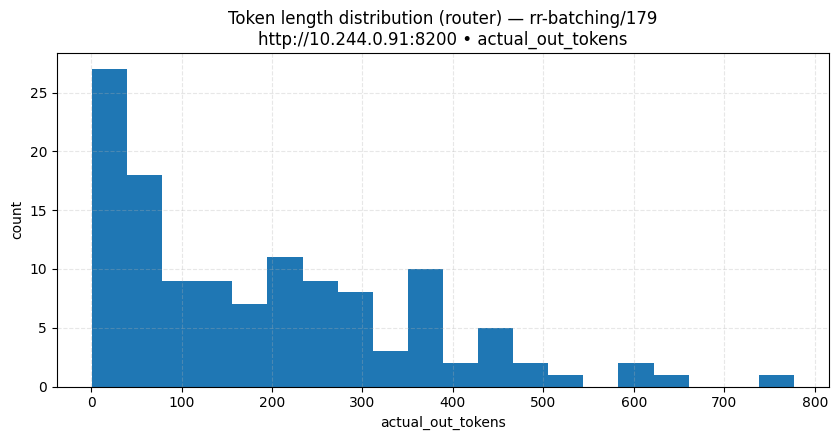

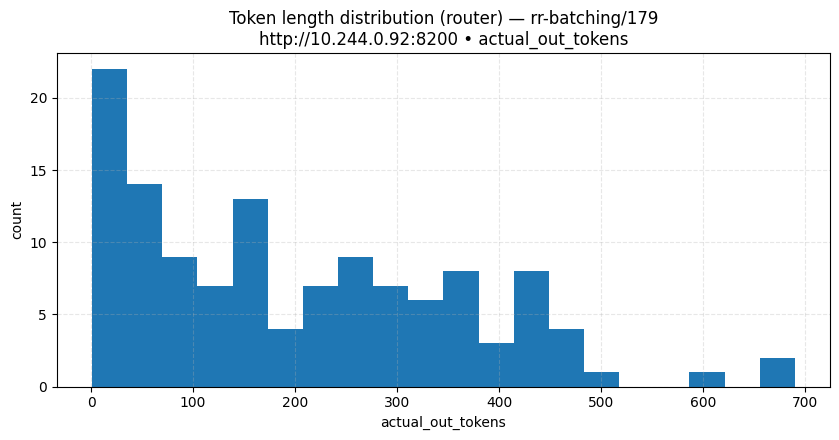

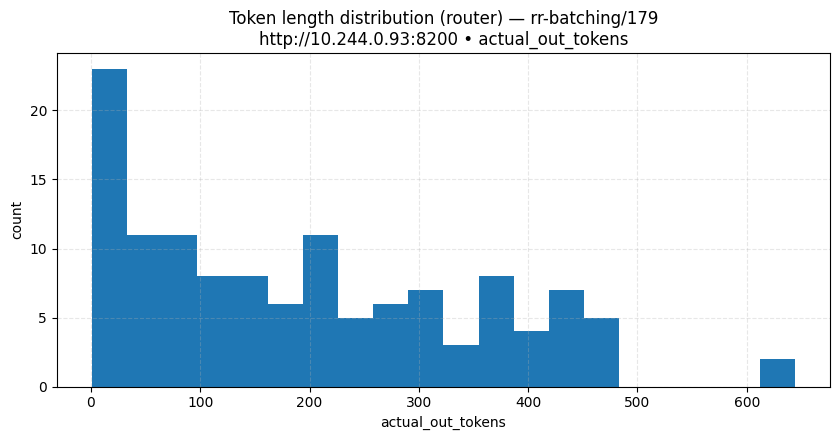

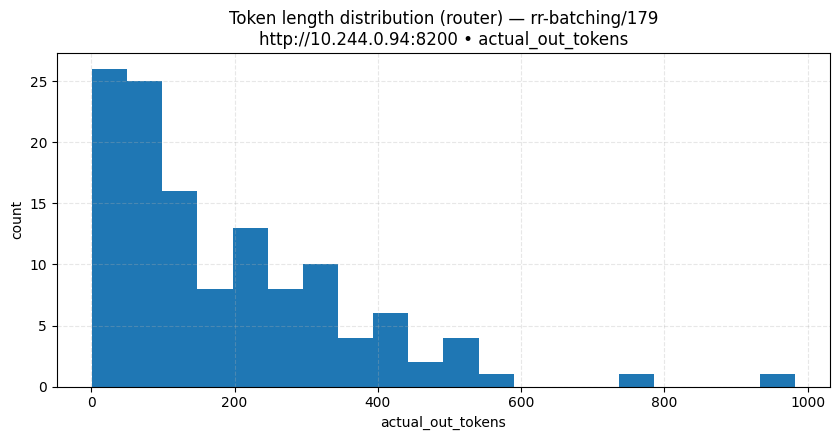

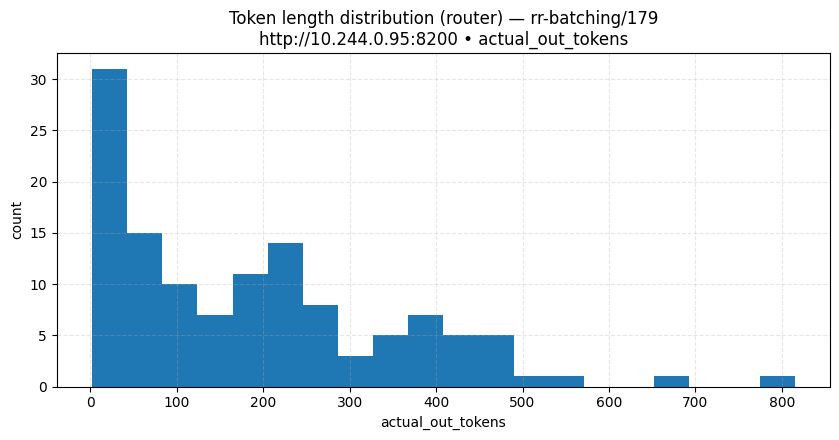

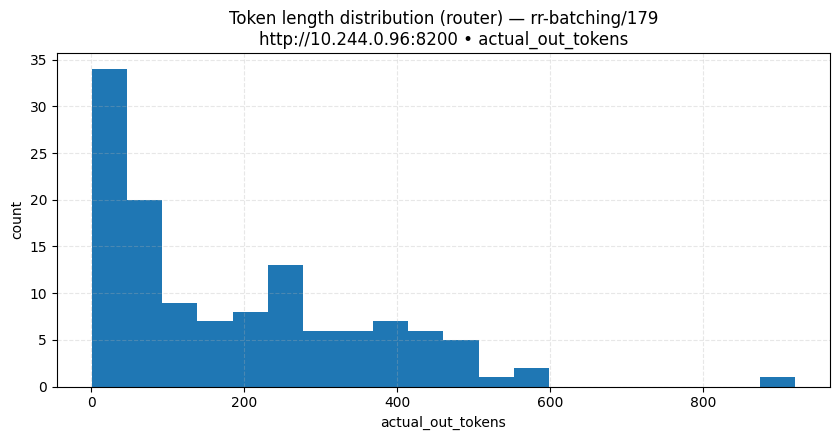

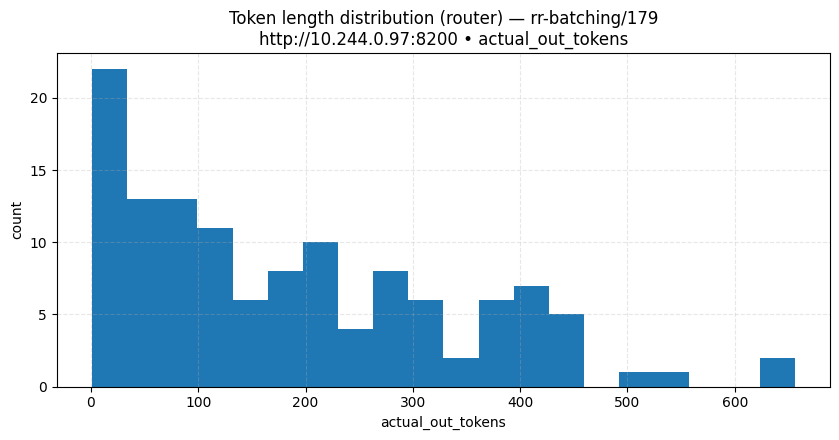

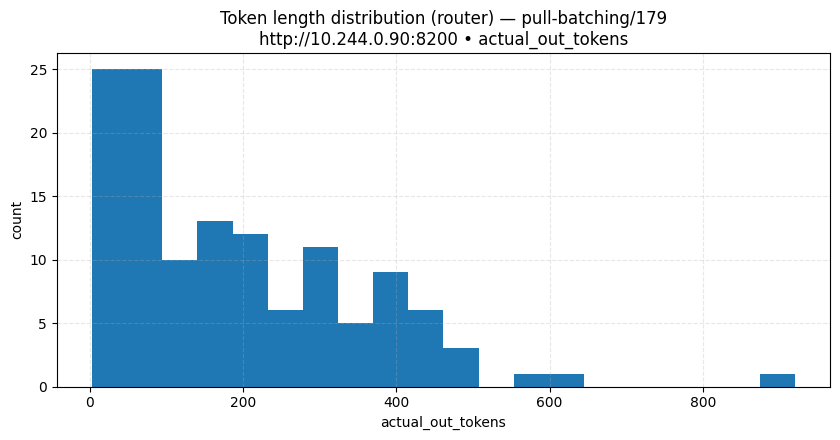

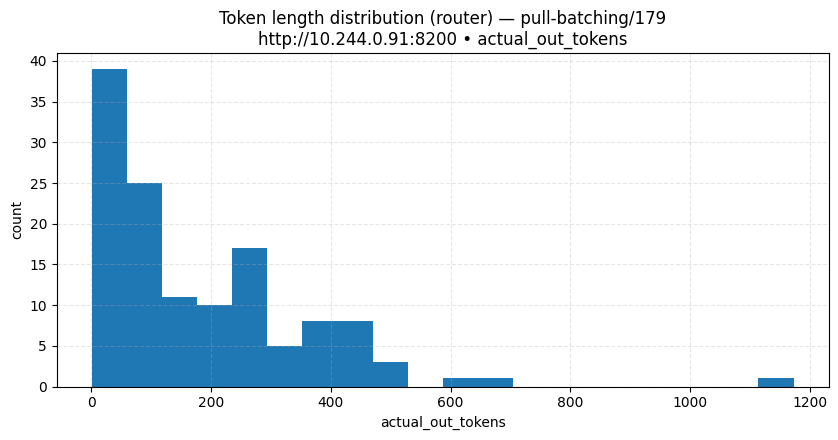

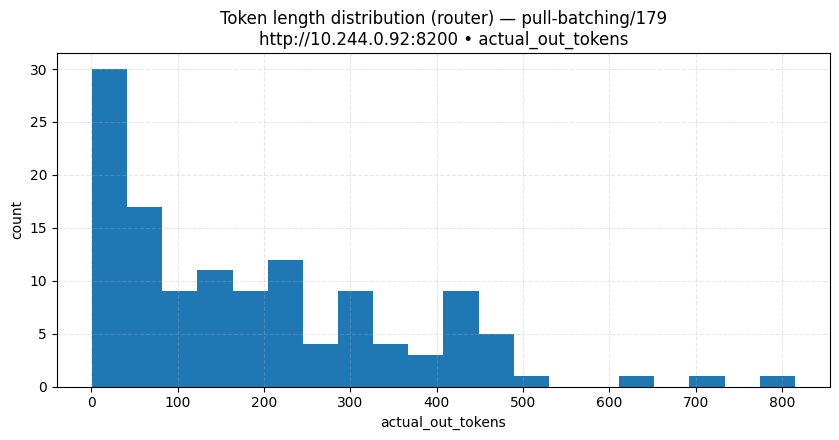

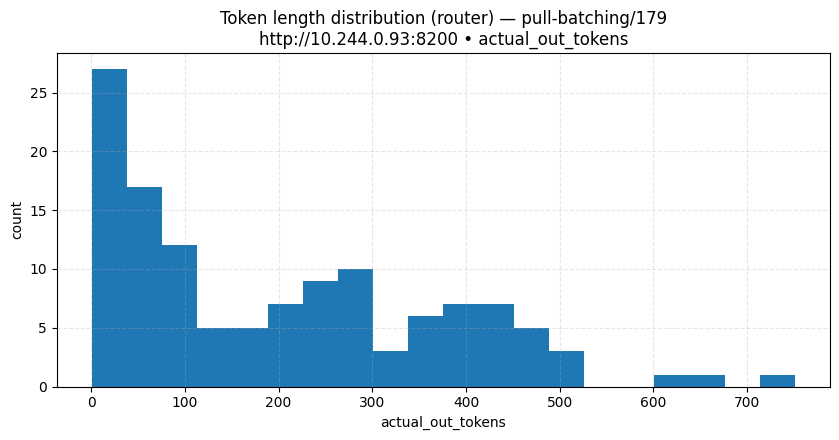

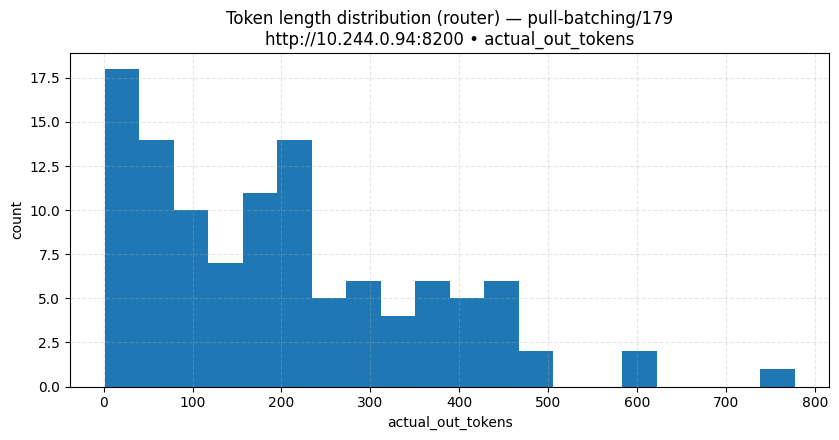

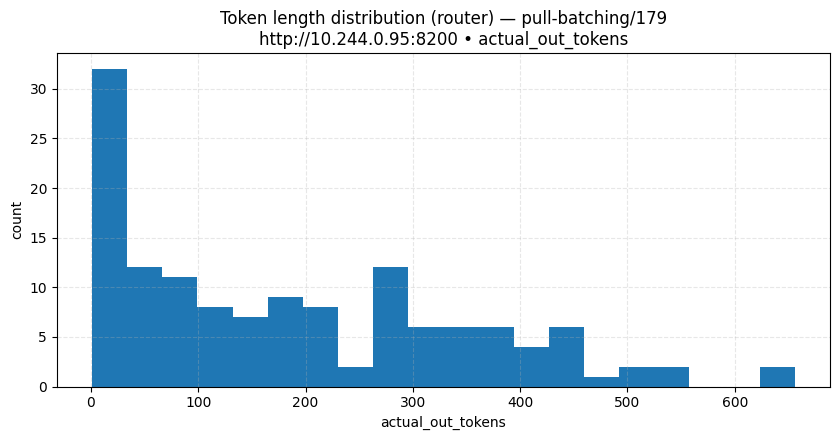

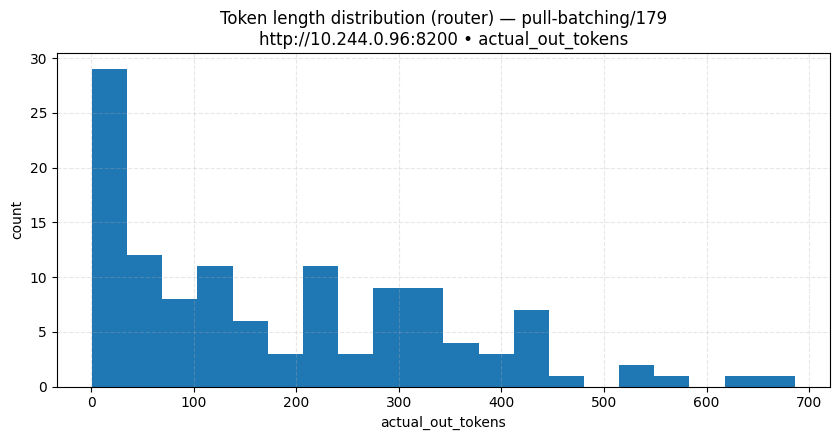

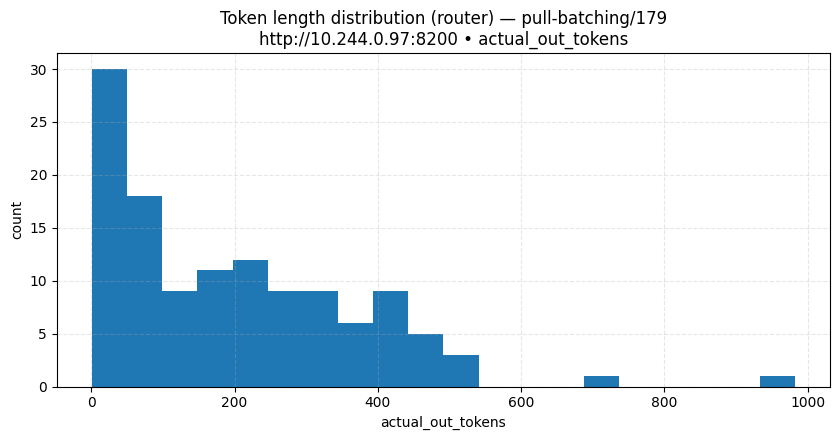

In [183]:
# ========================================
# 3) router output.jsonl — token-length distributions per endpoint
# ========================================

# Outgoing tokens per endpoint
draw_token_length_distribution_per_endpoint(
    "least-queue-batching", SERIES,
    token_col="actual_out_tokens",
    endpoints=None,
    base_dir=BASE_DIR,
    bins=20,
    density=False,
    title_prefix="Token length distribution (router)",
)

draw_token_length_distribution_per_endpoint(
    "rr-batching", SERIES,
    token_col="actual_out_tokens",
    endpoints=None,
    base_dir=BASE_DIR,
    bins=20,
    density=False,
    title_prefix="Token length distribution (router)",
)

draw_token_length_distribution_per_endpoint(
    "pull-batching", SERIES,
    token_col="actual_out_tokens",
    endpoints=None,
    base_dir=BASE_DIR,
    bins=20,
    density=False,
    title_prefix="Token length distribution (router)",
)


Collected 3,000 rows across 8 endpoints.


,method,run_id,endpoint,token
0,least-queue-batching,179,http://10.244.0.90:8200,1
1,least-queue-batching,179,http://10.244.0.91:8200,2
2,least-queue-batching,179,http://10.244.0.92:8200,2
3,least-queue-batching,179,http://10.244.0.93:8200,3
4,least-queue-batching,179,http://10.244.0.94:8200,3


,method,run_id,endpoint,count,mean,std,min,max,p50,p90,p95,p99
0,least-queue-batching,179,http://10.244.0.90:8200,125,193.392000,153.078300,1.0,646.0,168.0,424.6,451.00,573.20
1,least-queue-batching,179,http://10.244.0.91:8200,125,198.880000,169.156999,1.0,920.0,185.0,421.8,474.40,644.60
2,least-queue-batching,179,http://10.244.0.92:8200,125,202.912000,180.755405,1.0,982.0,157.0,438.0,475.80,646.84
3,least-queue-batching,179,http://10.244.0.93:8200,125,185.408000,156.666797,1.0,777.0,159.0,396.2,465.20,682.36
4,least-queue-batching,179,http://10.244.0.94:8200,125,185.512000,171.381371,1.0,1173.0,142.0,400.2,448.80,543.36
5,least-queue-batching,179,http://10.244.0.95:8200,125,182.248000,166.328457,1.0,686.0,118.0,435.8,474.20,645.68
6,least-queue-batching,179,http://10.244.0.96:8200,125,196.880000,159.586290,1.0,614.0,184.0,427.6,450.20,558.96
7,least-queue-batching,179,http://10.244.0.97:8200,125,189.168000,165.540013,1.0,815.0,152.0,414.8,443.00,736.36
8,pull-batching,179,http://10.244.0.90:8200,128,192.359375,163.230562,3.0,920.0,150.0,414.0,459.30,614.04
9,pull-batching,179,http://10.244.0.91:8200,129,182.217054,173.450730,1.0,1173.0,125.0,429.2,446.60,646.40


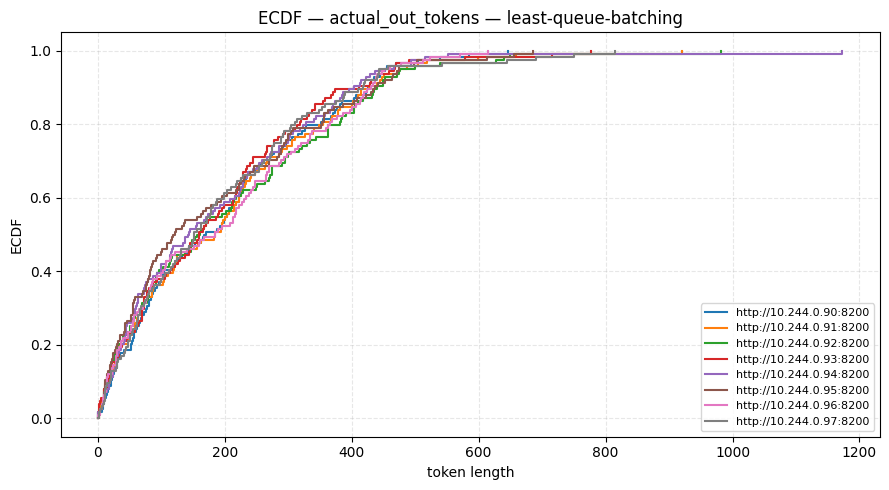

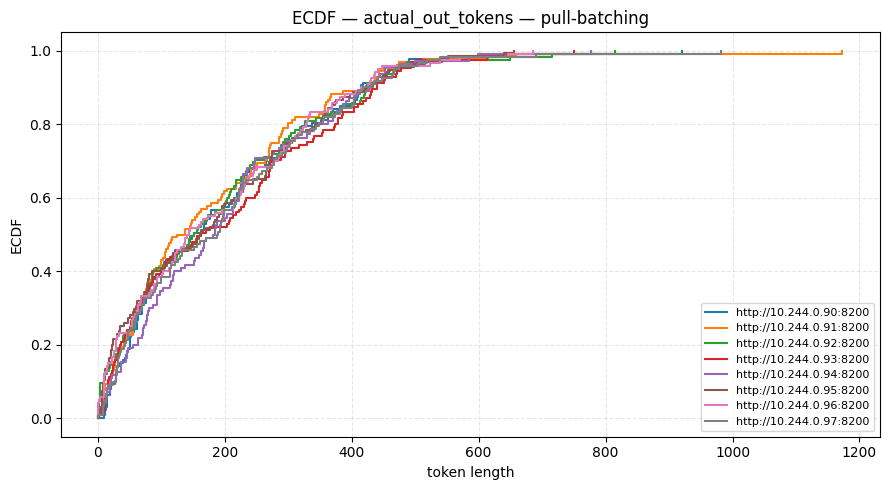

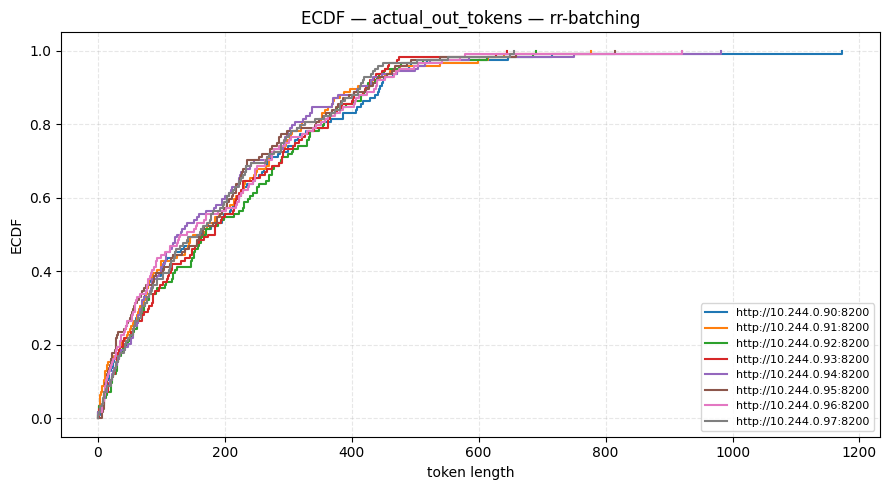

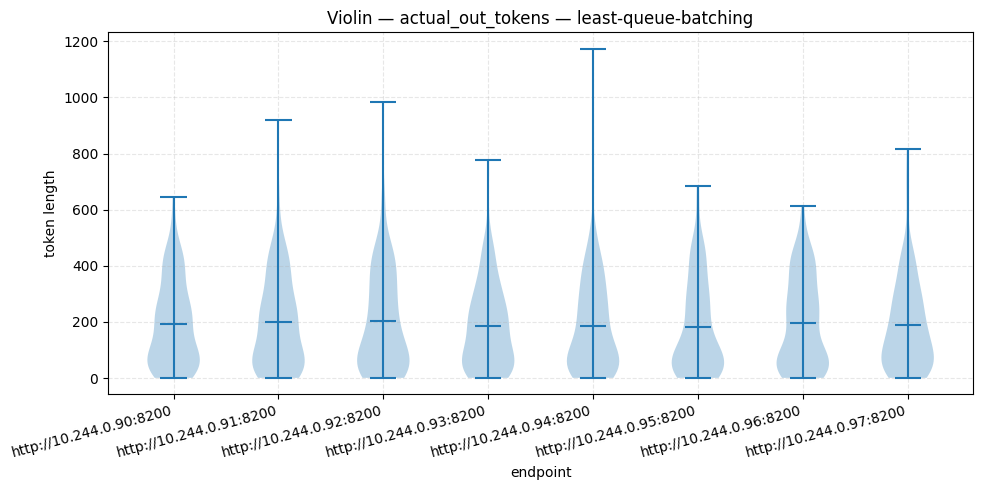

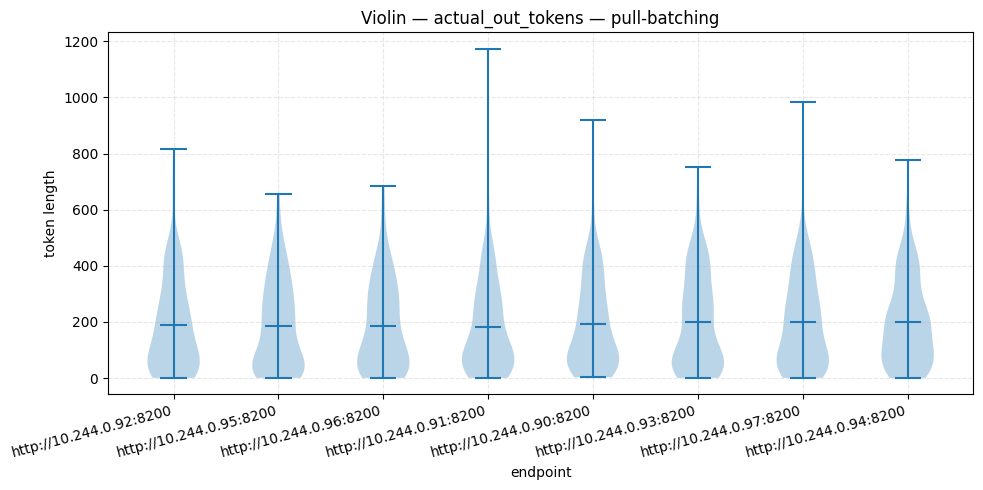

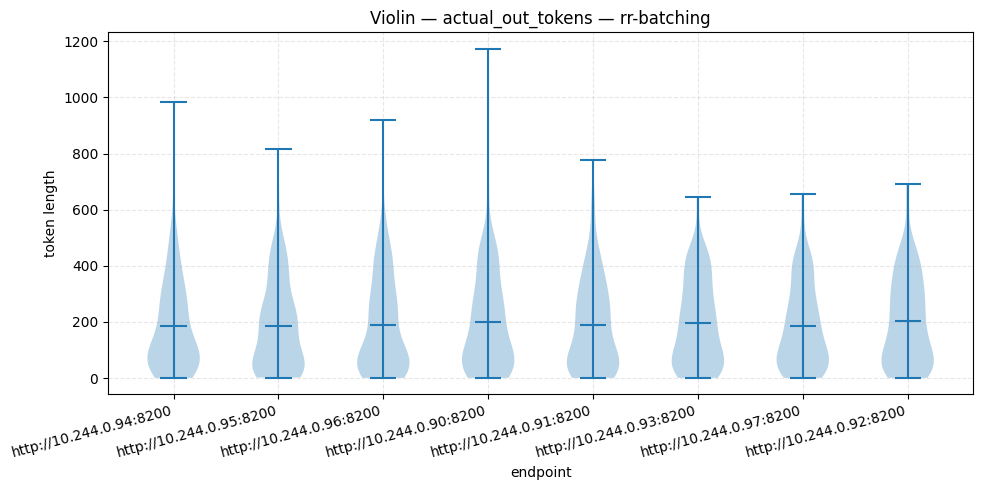

In [184]:
# ========================================
# Compare token-length distributions across endpoints per experiment
# ========================================

TOKEN_COL = "actual_out_tokens"
ENDPOINTS_FILTER = None  # or ["http://10.244.0.51:8200"]

tokens_ep = build_tokens_by_endpoint(
    experiments=EXPERIMENTS,
    base_dir=BASE_DIR,
    token_col=TOKEN_COL,
    endpoints=ENDPOINTS_FILTER,
)

print(f"Collected {len(tokens_ep):,} rows across {tokens_ep['endpoint'].nunique()} endpoints.")
display(tokens_ep.head())

endpoint_summary = summarize_by_endpoint(tokens_ep)
display(endpoint_summary)

plot_ecdf_per_method(tokens_ep, title_prefix=f"ECDF — {TOKEN_COL}")
plot_violins_per_method(tokens_ep, title_prefix=f"Violin — {TOKEN_COL}")


In [185]:
# draw_violin_for_metric(
#     {
#         "rr-batching": rr_batching_df,
#         "least-queue-batching": least_queue_df,
#         "pull-batching": pull_batching_df
#     },
#     value_col="p99",        # or "mean", "p50", "p90"
#     group_col="endpoint",
#     drop_overall=True,
#     title="Latency (p99) by strategy"
# )

In [186]:
# # Show full responses + response length grouped by prompt

# df_long = outputs_all[
#     ["prompt", "run_id", "method", "response_preview", "latency_s"]
# ].copy()

# # Add response length
# df_long["resp_len"] = df_long["response_preview"].astype(str).str.len()

# # Sort for readability
# df_long = df_long.sort_values(["prompt", "run_id"]).reset_index(drop=True)

# pd.set_option("display.max_colwidth", None)

# for prompt, group in df_long.groupby("prompt"):
#     print("=" * 120)
#     print(f"Prompt: {prompt}\n")
#     for _, row in group.iterrows():
#         label = f"{row['method']}/{row['run_id']} | latency={row['latency_s']:.2f}s | length={row['resp_len']}"
#         print(f"[{label}]\n{row['response_preview']}\n")

In [187]:
# print(outputs_all.columns)
# # Add a column with the length of each response_preview string
# outputs_all["prompt_len"] = outputs_all["response_preview"].fillna("").apply(len)

# print(outputs_all[["run_id", "mode", "prompt_len"]])

In [188]:
# # 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_queue_wait_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     ylim=None
# )

In [189]:
# # 2) output.jsonl — latency per request (points), separate figures
# draw_output_time_each(
#     EXPERIMENTS,
#     metric="sim_service_s",
#     endpoints=None,
#     base_dir=BASE_DIR,
#     per_request=True,  # raw events; resample ignored
#     resample=None,
#     title=None,
#     save_path_template=None,
#     ylim=None
# )

In [190]:
# import pandas as pd

# outputs_all = outputs_all.copy()

# # Reset exp_local_id inside each (run_id, mode)
# outputs_all["exp_local_id"] = outputs_all.groupby(["run_id", "mode"]).cumcount()

# def print_orders_only(df: pd.DataFrame, use_col: str = "exp_local_id"):
#     for (rid, mode), g in df.groupby(["run_id", "mode"], dropna=False, sort=True):
#         g = g.reset_index(drop=True)

#         gen  = g.sort_values(["t_enq_client_s",  "exp_local_id"])
#         sent = g.sort_values(["t_send_http_s",   "exp_local_id"])
#         recv = g.sort_values(["t_recv_http_s",   "exp_local_id"])

#         gen_order  = gen[use_col].tolist()
#         sent_order = sent[use_col].tolist()
#         recv_order = recv[use_col].tolist()

#         print("\n" + "="*80)
#         print(f"=== Experiment: run_id={rid}, mode={mode} ===")
#         print(f"- Generation order ({use_col}):")
#         print(gen_order)
#         print(f"- Sent order ({use_col}):")
#         print(sent_order)
#         print(f"- Received order ({use_col}):")
#         print(recv_order)
#         print("- Checks:")
#         print(f"  gen == sent ? {gen_order == sent_order}")
#         print(f"  gen == recv ? {gen_order == recv_order}")
#         print(f"  sent == recv ? {sent_order == recv_order}")
#         print("="*80)

# # run
# print_orders_only(outputs_all, use_col="exp_local_id")

In [191]:
# import numpy as np
# import pandas as pd

# # Show everything without truncation
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", 0)
# pd.set_option("display.max_colwidth", None)

# # Ensure we have a length column (character count of response_preview)
# if "prompt_len" not in outputs_all.columns:
#     outputs_all["prompt_len"] = outputs_all["response_preview"].fillna("").apply(len)

# def analyze_and_print_group(g, key):
#     rid, mode = key
#     # Reset row_id starting from 0 per experiment
#     g = g.copy().reset_index(drop=True).rename_axis("row_id").reset_index()

#     # Add generation rank (based on enqueue time if available)
#     if "t_enq_client_s" in g.columns:
#         g["gen_rank"] = g["t_enq_client_s"].rank(method="first").astype(int)
#     else:
#         g["gen_rank"] = g["t_send_http_s"].rank(method="first").astype(int)

#     # Sort by generation / send / receive
#     gen  = g.sort_values(["gen_rank", "row_id"])
#     sent = g.sort_values(["t_send_http_s", "row_id"])
#     recv = g.sort_values(["t_recv_http_s", "row_id"])

#     # Orders (per-experiment row_id)
#     gen_order_ids  = gen["row_id"].tolist()
#     sent_order_ids = sent["row_id"].tolist()
#     recv_order_ids = recv["row_id"].tolist()

#     # Map: for each item in send order, where did it land in receive order?
#     recv_pos = {rid_: i for i, rid_ in enumerate(recv_order_ids)}
#     sent_to_recv_positions = [recv_pos[r] for r in sent_order_ids]

#     # Length sequences
#     sent_lengths = sent["prompt_len"].tolist()
#     recv_lengths = recv["prompt_len"].tolist()

#     # Per-row rank table
#     ranks = g[["row_id","t_enq_client_s","t_send_http_s","t_recv_http_s","prompt_len"]].copy()
#     ranks["gen_rank"]  = g["gen_rank"]
#     ranks["send_rank"] = g["t_send_http_s"].rank(method="first").astype(int)
#     ranks["recv_rank"] = g["t_recv_http_s"].rank(method="first").astype(int)

#     # ---- Print EVERYTHING for this experiment ----
#     print("\n" + "=" * 80)
#     print(f"=== Experiment: run_id={rid}, mode={mode} ===")
#     print("- Generation order (row_id):")
#     print(gen_order_ids)
#     print("- Sent order (row_id):")
#     print(sent_order_ids)
#     print("- Received order (row_id):")
#     print(recv_order_ids)
#     print("- Sent→Recv position map (index in recv order for each item in sent order):")
#     print(sent_to_recv_positions)
#     print("- Lengths in sent order (prompt_len):")
#     print(sent_lengths)
#     print("- Lengths in received order (prompt_len):")
#     print(recv_lengths)
#     print("- Per-row ranks (full):")
#     print(ranks.sort_values(["gen_rank","send_rank","recv_rank"]).to_string(index=False))
#     print("=" * 80 + "\n")

#     return {
#         "gen_order_ids": gen_order_ids,
#         "sent_order_ids": sent_order_ids,
#         "recv_order_ids": recv_order_ids,
#         "sent_to_recv_positions": sent_to_recv_positions,
#         "sent_lengths": sent_lengths,
#         "recv_lengths": recv_lengths,
#         "ranks_df": ranks.assign(run_id=rid, mode=mode)
#     }

# # Run for every (run_id, mode) experiment and print full details
# results = {}
# for key, grp in outputs_all.groupby(["run_id", "mode"], dropna=False):
#     results[key] = analyze_and_print_group(grp, key)

# # If you also want a single DataFrame with all rows from all experiments:
# all_ranks = pd.concat([v["ranks_df"] for v in results.values()], ignore_index=True)

# # Optional: save full per-experiment ranks to CSV if you want files later
# # all_ranks.to_csv("all_experiments_send_recv_ranks.csv", index=False)

In [192]:
# from utils_analysis import draw_metric_time

# method = "rr-batching"
# run_id = "9"
# metric = "requests_running"  # e.g., "gpu_util_percent", "gen_tokens_per_sec"
# endpoints = None  # or ["http://10.1.62.151:8200"]
# resample = None  # e.g., "1S" to bin by 1 second (mean)
# title = None
# save_to = None

# draw_metric_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )

In [193]:
# from utils_analysis import draw_output_time

# method = "rr-batching"
# run_id = "9"
# metric = "latency_s"
# endpoints = None
# # When per_request=True, resample is ignored
# draw_output_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=None,
#     per_request=True,  # raw per-request points
#     title=None,
#     save_path=None,
# )

In [194]:
# from utils_analysis import draw_output_time

# method = "rr-batching"
# run_id = "9"
# metric = "latency_s"  # request/event-driven; use mean when resampling
# endpoints = None
# resample = "1S"  # optional smoothing
# title = None
# save_to = None

# draw_output_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )

In [195]:
# from utils_analysis import draw_queue_time

# method = "rr-batching"
# run_id = "10"
# metric = "inflight_after"  # state-driven; plotted as steps
# endpoints = None
# resample = "0.1S"  # optional; uses last+ffill per bin
# title = None
# save_to = None

# draw_queue_time(
#     method,
#     run_id,
#     metric,
#     endpoints=endpoints,
#     base_dir=BASE_DIR,
#     resample=resample,
#     title=title,
#     save_path=save_to,
# )